In [1]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 91.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 94.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.utils.validation import check_is_fitted

from xgboost import XGBRegressor

import mlflow
import mlflow.sklearn
import dagshub

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('imports ok')


imports ok


In [3]:
CANDIDATE_DIRS = [
    os.environ.get('WALMART_DATA_DIR', ''),
    '/kaggle/working',
    '/kaggle/input',
    '.',
    './data',
]
CANDIDATE_DIRS = [d for d in CANDIDATE_DIRS if d]
DATA_DIR = None
for d in CANDIDATE_DIRS:
    if os.path.exists(os.path.join(d, 'train_features.parquet')):
        DATA_DIR = d
        break
if DATA_DIR is None and os.path.isdir('/kaggle/input'):
    for root, _, files in os.walk('/kaggle/input'):
        if 'train_features.parquet' in files:
            DATA_DIR = root
            break
if DATA_DIR is None:
    raise FileNotFoundError(
        'train_features.parquet not found. Run the EDA notebook first, then ensure '
        'train_features.parquet / test_features.parquet / feature_cols.json are in '
        '/kaggle/working or under /kaggle/input.'
    )
print('DATA_DIR =', DATA_DIR)

import dagshub 

DAGSHUB_OWNER = 'ejoba22'
DAGSHUB_REPO = 'walmart-sales-forecasting'
dagshub.init(repo_owner=DAGSHUB_OWNER, repo_name=DAGSHUB_REPO, mlflow=True)
use_dagshub = True
EXPERIMENT_NAME = 'XGBoost_Training'
mlflow.set_experiment(EXPERIMENT_NAME)
print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Experiment:', EXPERIMENT_NAME)

DATA_DIR = /kaggle/input/datasets/elenejobava/walmart-features-engineered


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d7890d8c-d6cf-4a5d-90f0-a3db96551067&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d435bf57327a34f1be4cfd42934893e32d1d7bad5014dc4334bb5de6c9f5d3a8




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

MLflow tracking URI: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow
Experiment: XGBoost_Training


## 1. Load EDA features + MLflow run: `XGBoost_Cleaning`

In [4]:
with mlflow.start_run(run_name='XGBoost_Cleaning') as run:
    train_fe = pd.read_parquet(os.path.join(DATA_DIR, 'train_features.parquet'))
    test_fe  = pd.read_parquet(os.path.join(DATA_DIR, 'test_features.parquet'))

    with open(os.path.join(DATA_DIR, 'feature_cols.json')) as f:
        base_feature_cols = json.load(f)

    train_fe['Date'] = pd.to_datetime(train_fe['Date'])
    test_fe['Date']  = pd.to_datetime(test_fe['Date'])
    train_fe = train_fe.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
    test_fe  = test_fe.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

    train_fe['IsHoliday'] = train_fe['IsHoliday'].astype(int)
    test_fe['IsHoliday']  = test_fe['IsHoliday'].astype(int)

    mlflow.log_param('train_rows', len(train_fe))
    mlflow.log_param('test_rows', len(test_fe))
    mlflow.log_param('n_base_features', len(base_feature_cols))
    mlflow.log_param('train_start', str(train_fe.Date.min().date()))
    mlflow.log_param('train_end', str(train_fe.Date.max().date()))
    mlflow.log_param('test_start', str(test_fe.Date.min().date()))
    mlflow.log_param('test_end', str(test_fe.Date.max().date()))

    print(f'train_fe: {train_fe.shape}, test_fe: {test_fe.shape}')
    print(f'Date range train: {train_fe.Date.min().date()} -> {train_fe.Date.max().date()}')
    print(f'Date range test : {test_fe.Date.min().date()} -> {test_fe.Date.max().date()}')
    print(f'Unique train weeks: {train_fe.Date.nunique()} | test weeks: {test_fe.Date.nunique()}')


train_fe: (421570, 57), test_fe: (115064, 56)
Date range train: 2010-02-05 -> 2012-10-26
Date range test : 2012-11-02 -> 2013-07-26
Unique train weeks: 143 | test weeks: 39
🏃 View run XGBoost_Cleaning at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/54f8df6edd184b2d9c013b07938f0af2
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0


## 2. Horizon-safe lag / rolling features

In [5]:
# How far must we forecast?
train_end = train_fe['Date'].max()
test_end  = test_fe['Date'].max()
HORIZON_WEEKS = int(round((test_end - train_end).days / 7.0))
print(f'Detected forecast horizon: {HORIZON_WEEKS} weeks')

# Calendar lags: seasonal + mid-horizon (13/26 help early test weeks; 52 is the anchor)
SAFE_LAGS = sorted(set([13, 26, max(HORIZON_WEEKS, 39), 52, 53, 56, 65, 78, 104]))
SAFE_ROLLING = [4, 8, 13, 26, 39, 52]

# Frozen recent history at forecast origin (replaces dangerous recursive short lags on test)
ORIGIN_LAGS = [1, 2, 3, 4, 5, 6, 8, 12]

# Train on log1p — usually stabilises large departments; invert with expm1 at predict
USE_LOG_TARGET = True

print('SAFE_LAGS:', SAFE_LAGS)
print('SAFE_ROLLING:', SAFE_ROLLING)
print('ORIGIN_LAGS:', ORIGIN_LAGS)
print('USE_LOG_TARGET:', USE_LOG_TARGET)

# Drop ALL previous lag/rolling/origin cols — we rebuild a clean set
old_ts_cols = [
    c for c in train_fe.columns
    if c.startswith('lag_') or c.startswith('rolling_') or c.startswith('origin_')
    or c in ('expanding_mean', 'weeks_since_train_end', 'last_known_sales', 'origin_1_to_lag52')
    or c.endswith('_x') or c.endswith('_y')  # leftover merge suffixes from re-runs
]
train_fe = train_fe.drop(columns=old_ts_cols, errors='ignore')
test_fe  = test_fe.drop(columns=[c for c in old_ts_cols if c in test_fe.columns], errors='ignore')
print(f'Dropped {len(old_ts_cols)} old lag/rolling/origin columns')


Detected forecast horizon: 39 weeks
SAFE_LAGS: [13, 26, 39, 52, 53, 56, 65, 78, 104]
SAFE_ROLLING: [4, 8, 13, 26, 39, 52]
ORIGIN_LAGS: [1, 2, 3, 4, 5, 6, 8, 12]
USE_LOG_TARGET: True
Dropped 0 old lag/rolling/origin columns


In [6]:
def add_ts_features(train_df, test_df, lags, rolling_windows, origin_lags):
    '''Calendar lags + rolling + frozen origin recent-sales features.'''
    combined = pd.concat([
        train_df[['Store', 'Dept', 'Date', 'Weekly_Sales']],
        test_df[['Store', 'Dept', 'Date']].assign(Weekly_Sales=np.nan),
    ], ignore_index=True)
    combined = combined.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

    g = combined.groupby(['Store', 'Dept'], sort=False)['Weekly_Sales']
    for lag in lags:
        combined[f'lag_{lag}'] = g.shift(lag)

    shifted = g.shift(1)
    keys = [combined['Store'], combined['Dept']]
    for window in rolling_windows:
        rolled = shifted.groupby(keys)
        combined[f'rolling_mean_{window}'] = rolled.transform(
            lambda s: s.rolling(window, min_periods=1).mean())
        combined[f'rolling_std_{window}'] = rolled.transform(
            lambda s: s.rolling(window, min_periods=1).std())
        combined[f'rolling_max_{window}'] = rolled.transform(
            lambda s: s.rolling(window, min_periods=1).max())

    combined['expanding_mean'] = shifted.groupby(keys).transform(
        lambda s: s.expanding(min_periods=1).mean())

    last_train = (
        train_df.sort_values('Date')
        .groupby(['Store', 'Dept'])['Weekly_Sales']
        .last()
        .rename('last_known_sales')
    )
    combined = combined.join(last_train, on=['Store', 'Dept'])

    # Origin features: on TRAIN = normal short lags; on TEST = frozen last-k train sales
    for k in origin_lags:
        combined[f'origin_{k}'] = g.shift(k)

    t_end = train_df['Date'].max()
    combined['weeks_since_train_end'] = (combined['Date'] - t_end).dt.days / 7.0

    new_cols = [
        c for c in combined.columns
        if c.startswith('lag_') or c.startswith('rolling_') or c.startswith('origin_')
        or c in ('expanding_mean', 'last_known_sales', 'weeks_since_train_end')
    ]
    key = ['Store', 'Dept', 'Date']
    train_out = train_df.merge(combined[key + new_cols], on=key, how='left')
    test_out  = test_df.merge(combined[key + new_cols], on=key, how='left')

    # Overwrite TEST origin_* with frozen values from the last train weeks (no NaN cascade)
    origin_map = {}
    for (store, dept), grp in train_df.groupby(['Store', 'Dept']):
        s = grp.sort_values('Date')['Weekly_Sales'].to_numpy()
        for k in origin_lags:
            origin_map[(store, dept, k)] = s[-k] if len(s) >= k else np.nan

    for k in origin_lags:
        col = f'origin_{k}'
        test_out[col] = [
            origin_map.get((st, dp, k), np.nan)
            for st, dp in zip(test_out['Store'], test_out['Dept'])
        ]

    # Ratios vs recent level (strong for trees)
    train_out['origin_1_to_lag52'] = train_out['origin_1'] / train_out['lag_52'].replace(0, np.nan)
    test_out['origin_1_to_lag52']  = test_out['origin_1'] / test_out['lag_52'].replace(0, np.nan)
    new_cols = new_cols + ['origin_1_to_lag52']

    return train_out, test_out, new_cols


with mlflow.start_run(run_name='XGBoost_Feature_Engineering'):
    train_fe, test_fe, new_feat_cols = add_ts_features(
        train_fe, test_fe, SAFE_LAGS, SAFE_ROLLING, ORIGIN_LAGS
    )
    mlflow.log_param('horizon_weeks', HORIZON_WEEKS)
    mlflow.log_param('safe_lags', SAFE_LAGS)
    mlflow.log_param('safe_rolling', SAFE_ROLLING)
    mlflow.log_param('origin_lags', ORIGIN_LAGS)
    mlflow.log_param('use_log_target', USE_LOG_TARGET)
    mlflow.log_param('n_new_ts_features', len(new_feat_cols))
    print(f'Computed {len(new_feat_cols)} TS features (calendar + origin)')
    print(f'train_fe: {train_fe.shape}, test_fe: {test_fe.shape}')
    # Sanity: origin features should be dense on test
    oc = [c for c in new_feat_cols if c.startswith('origin_')]
    print('Test origin missing %:\n', (test_fe[oc].isnull().mean() * 100).round(2))


Computed 39 TS features (calendar + origin)
train_fe: (421570, 96), test_fe: (115064, 95)
Test origin missing %:
 origin_1             0.03
origin_2             0.07
origin_3             0.09
origin_4             0.12
origin_5             0.13
origin_6             0.16
origin_8             0.19
origin_12            0.26
origin_1_to_lag52    1.17
dtype: float64
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/bb735c7815c741b09c42495f9235a450
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0


## Fix

In [7]:
def compute_frozen_origin(history_df, query_df, cutoff_date, origin_lags):
    '''Frozen origin_* features as of cutoff_date, mirroring the real Kaggle-test
    behavior (last known sales at the forecast origin, held fixed across the horizon).
    history_df: Store, Dept, Date, Weekly_Sales with Date <= cutoff_date.
    query_df:   Store, Dept for the rows to attach frozen features to.
    Returns a DataFrame aligned to query_df.index.
    '''
    hist = history_df[history_df['Date'] <= cutoff_date]
    origin_map = {}
    for (store, dept), grp in hist.groupby(['Store', 'Dept']):
        s = grp.sort_values('Date')['Weekly_Sales'].to_numpy()
        for k in origin_lags:
            origin_map[(store, dept, k)] = s[-k] if len(s) >= k else np.nan

    out = pd.DataFrame(index=query_df.index)
    for k in origin_lags:
        out[f'origin_{k}'] = [
            origin_map.get((st, dp, k), np.nan)
            for st, dp in zip(query_df['Store'], query_df['Dept'])
        ]
    return out


def apply_frozen_origin(df, tr_idx, va_idx, origin_lags, lag52_col='lag_52'):
    '''Return a copy of the validation rows with origin_* (and origin_1_to_lag52)
    overwritten by values frozen at the fold's train cutoff -- exactly mirroring
    what the model sees at real, long-horizon inference time.'''
    cutoff = df.loc[tr_idx, 'Date'].max()
    history = df.loc[tr_idx, ['Store', 'Dept', 'Date', 'Weekly_Sales']]
    query = df.loc[va_idx, ['Store', 'Dept']]
    frozen = compute_frozen_origin(history, query, cutoff, origin_lags)

    X_va = df.loc[va_idx].copy()
    for col in frozen.columns:
        if col in X_va.columns:
            X_va[col] = frozen[col].values
    if 'origin_1' in X_va.columns and lag52_col in X_va.columns:
        X_va['origin_1_to_lag52'] = X_va['origin_1'] / X_va[lag52_col].replace(0, np.nan)
    return X_va


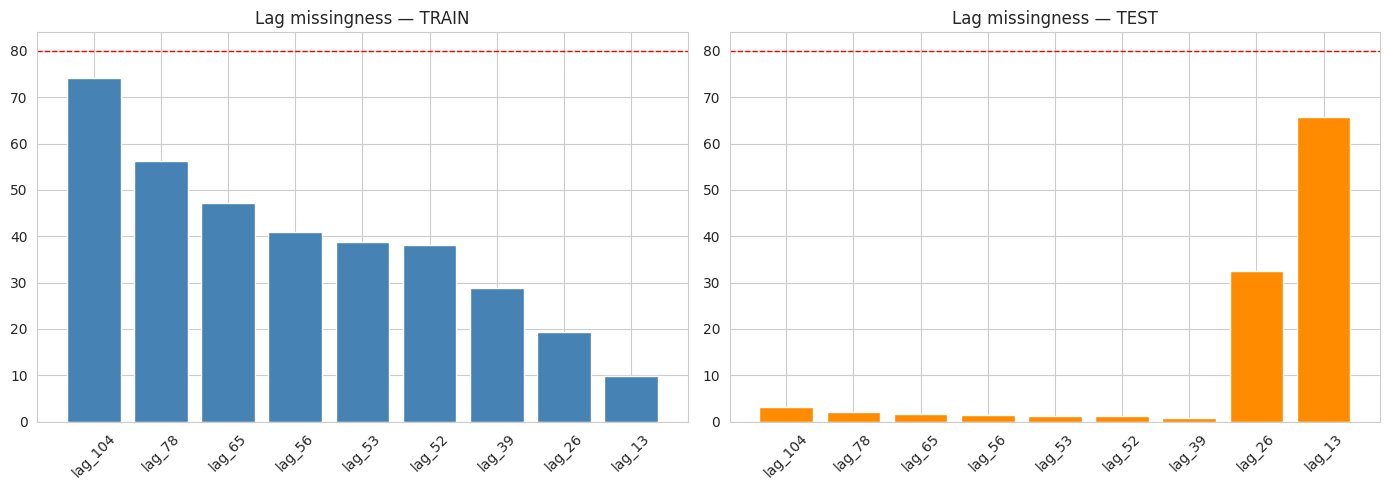

Train missing %:
 lag_104                  74.2
lag_78                   56.3
lag_65                   47.2
lag_56                   40.9
lag_53                   38.8
origin_1_to_lag52        38.1
lag_52                   38.1
lag_39                   28.8
lag_26                   19.4
lag_13                    9.9
origin_12                 9.2
origin_8                  6.2
origin_6                  4.6
origin_5                  3.9
origin_4                  3.1
origin_3                  2.3
rolling_std_52            1.6
rolling_std_4             1.6
rolling_std_8             1.6
rolling_std_26            1.6
rolling_std_39            1.6
rolling_std_13            1.6
origin_2                  1.6
rolling_mean_39           0.8
rolling_max_26            0.8
rolling_max_13            0.8
rolling_mean_26           0.8
rolling_mean_13           0.8
rolling_max_4             0.8
rolling_mean_8            0.8
rolling_max_8             0.8
rolling_mean_4            0.8
origin_1              

In [8]:
# Missingness check — only columns that actually exist after FE
new_feat_cols = [c for c in new_feat_cols if c in train_fe.columns and c in test_fe.columns]
missing_cols = [c for c in new_feat_cols if c not in train_fe.columns]
if missing_cols:
    print('Warning: skipping missing new_feat_cols:', missing_cols)

missing_train = train_fe[new_feat_cols].isnull().mean().sort_values(ascending=False) * 100
missing_test  = test_fe[new_feat_cols].isnull().mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lag_cols = [c for c in missing_train.index if c.startswith('lag_')]
axes[0].bar(lag_cols, missing_train[lag_cols], color='steelblue')
axes[0].set_title('Lag missingness — TRAIN')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(80, color='red', ls='--', lw=1)

axes[1].bar(lag_cols, missing_test.reindex(lag_cols).fillna(0), color='darkorange')
axes[1].set_title('Lag missingness — TEST')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(80, color='red', ls='--', lw=1)

plt.tight_layout()
plt.savefig('fig_lag_missingness.png', bbox_inches='tight')
plt.show()

print('Train missing %:\n', missing_train.round(1))
print('\nTest missing %:\n', missing_test.round(1))
print('origin_* test missing %:\n', missing_test[[c for c in missing_test.index if c.startswith('origin_')]].round(1))


## 3.Feature Selection

In [9]:
with mlflow.start_run(run_name='XGBoost_Feature_Selection') as run:
    # Drop only extremely sparse lag columns on TRAIN (early series has no history yet)
    DROP_THRESHOLD = 92.0
    too_sparse = missing_train[missing_train > DROP_THRESHOLD].index.tolist()
    if too_sparse:
        print(f'Dropping {len(too_sparse)} cols > {DROP_THRESHOLD}% missing on train: {too_sparse}')
        train_fe = train_fe.drop(columns=too_sparse)
        test_fe  = test_fe.drop(columns=[c for c in too_sparse if c in test_fe.columns])
        new_feat_cols = [c for c in new_feat_cols if c not in too_sparse]
    else:
        print('No lag column exceeds sparsity threshold — keeping all.')

    # Base non-lag columns from EDA (calendar, markdowns, dept stats, ...)
    base_non_lag = [
        c for c in base_feature_cols
        if c in train_fe.columns
        and not (c.startswith('lag_') or c.startswith('rolling_') or c == 'expanding_mean')
        and c not in ('Weekly_Sales',)
    ]

    feature_cols = base_non_lag + new_feat_cols
    feature_cols = [c for c in feature_cols if c in train_fe.columns]

    # Keep only numeric / bool features for the tree model
    numeric_mask = train_fe[feature_cols].dtypes.apply(
        lambda t: np.issubdtype(t, np.number) or str(t) == 'bool'
    )
    dropped_non_numeric = [c for c, ok in zip(feature_cols, numeric_mask) if not ok]
    feature_cols = [c for c, ok in zip(feature_cols, numeric_mask) if ok]
    if dropped_non_numeric:
        print('Dropped non-numeric:', dropped_non_numeric)

    TARGET = 'Weekly_Sales'
    train_fe = train_fe.sort_values('Date').reset_index(drop=True)

    mlflow.log_param('drop_threshold', DROP_THRESHOLD)
    mlflow.log_param('n_features', len(feature_cols))
    mlflow.log_param('n_lag_features', sum(c.startswith('lag_') for c in feature_cols))
    mlflow.log_param('n_rolling_features', sum(c.startswith('rolling_') for c in feature_cols))
    with open('feature_cols_xgboost.json', 'w') as f:
        json.dump(feature_cols, f)
    mlflow.log_artifact('feature_cols_xgboost.json')

    print(f'Final feature count: {len(feature_cols)}')
    print(train_fe[feature_cols].dtypes.value_counts())


No lag column exceeds sparsity threshold — keeping all.
Final feature count: 92
float64    66
int64      21
int32       5
Name: count, dtype: int64
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/9462ab4ee7a74d61879b9f1902370c58
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0


## 4. Metrics

train weeks:  28 (2010-02-05 -> 2010-08-13)   |   val weeks:  23 (2010-08-20 -> 2011-01-21)
train weeks:  51 (2010-02-05 -> 2011-01-21)   |   val weeks:  23 (2011-01-28 -> 2011-07-01)
train weeks:  74 (2010-02-05 -> 2011-07-01)   |   val weeks:  23 (2011-07-08 -> 2011-12-09)
train weeks:  97 (2010-02-05 -> 2011-12-09)   |   val weeks:  23 (2011-12-16 -> 2012-05-18)
train weeks: 120 (2010-02-05 -> 2012-05-18)   |   val weeks:  23 (2012-05-25 -> 2012-10-26)
Fold 1: train rows =   82022, val rows =  67433
Fold 2: train rows =  149455, val rows =  67693
Fold 3: train rows =  217148, val rows =  67941
Fold 4: train rows =  285089, val rows =  68459
Fold 5: train rows =  353548, val rows =  68022


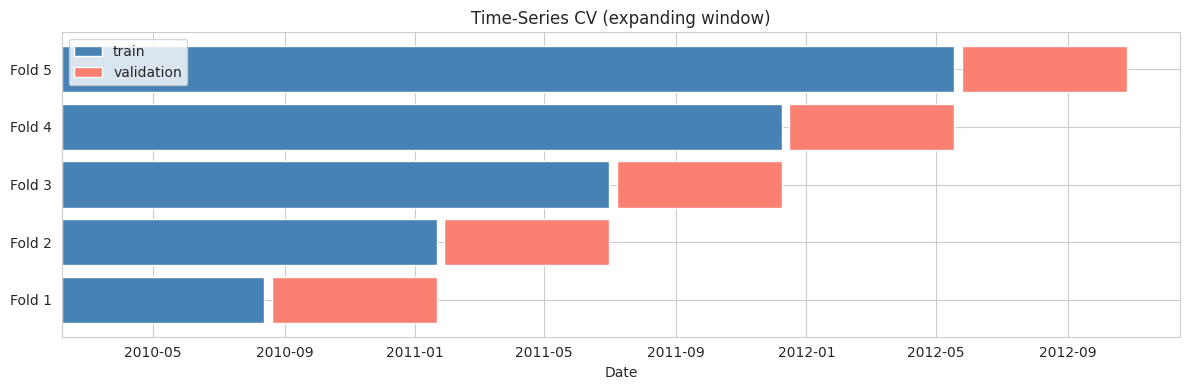

In [10]:
def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday).astype(bool), 5.0, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def evaluate_predictions(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'wmae': wmae(y_true, y_pred, is_holiday),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
    }


N_SPLITS = 5
unique_dates = np.sort(train_fe['Date'].unique())
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

date_folds = []
for train_date_idx, val_date_idx in tscv.split(unique_dates):
    train_dates = unique_dates[train_date_idx]
    val_dates = unique_dates[val_date_idx]
    date_folds.append((train_dates, val_dates))
    print(
        f'train weeks: {len(train_dates):>3} '
        f'({pd.Timestamp(train_dates[0]).date()} -> {pd.Timestamp(train_dates[-1]).date()})'
        f'   |   val weeks: {len(val_dates):>3} '
        f'({pd.Timestamp(val_dates[0]).date()} -> {pd.Timestamp(val_dates[-1]).date()})'
    )


def rows_for_dates(df, dates):
    return df.index[df['Date'].isin(dates)]


row_folds = [(rows_for_dates(train_fe, tr), rows_for_dates(train_fe, va)) for tr, va in date_folds]
for i, (tr_idx, va_idx) in enumerate(row_folds):
    print(f'Fold {i+1}: train rows = {len(tr_idx):>7}, val rows = {len(va_idx):>6}')

fig, ax = plt.subplots(figsize=(12, 4))
for i, (train_dates, val_dates) in enumerate(date_folds):
    ax.barh(i, (train_dates[-1] - train_dates[0]) / np.timedelta64(1, 'D'),
            left=train_dates[0], color='steelblue', label='train' if i == 0 else None)
    ax.barh(i, (val_dates[-1] - val_dates[0]) / np.timedelta64(1, 'D'),
            left=val_dates[0], color='salmon', label='validation' if i == 0 else None)
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f'Fold {i+1}' for i in range(N_SPLITS)])
ax.set_xlabel('Date')
ax.set_title('Time-Series CV (expanding window)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig_cv_scheme.png', bbox_inches='tight')
plt.show()


## 5. Pipeline

In [11]:
lag_rolling_cols = [
    c for c in feature_cols
    if c.startswith('lag_') or c.startswith('rolling_') or c.startswith('origin_')
    or c in ('expanding_mean', 'last_known_sales', 'weeks_since_train_end', 'origin_1_to_lag52')
]
other_cols = [c for c in feature_cols if c not in lag_rolling_cols]
PIPELINE_FEATURE_ORDER = lag_rolling_cols + other_cols

preprocessor = ColumnTransformer(
    transformers=[
        ('lag_impute', SimpleImputer(strategy='median', keep_empty_features=True), lag_rolling_cols),
        ('passthrough_other', 'passthrough', other_cols),
    ],
    remainder='drop',
)

BASELINE_COL = 'store_dept_week_avg' if 'store_dept_week_avg' in feature_cols else None
print('Seasonal baseline column:', BASELINE_COL)


def build_pipeline(xgb_params):
    params = {
        'objective': 'reg:squarederror',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'tree_method': 'hist',
        'enable_categorical': False,
    }
    params.update(xgb_params)
    return Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', XGBRegressor(**params)),
    ])


def transform_target(y):
    y = np.asarray(y, dtype=float)
    if USE_LOG_TARGET:
        return np.log1p(np.clip(y, 0, None))
    return y


def invert_target(y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    if USE_LOG_TARGET:
        return np.expm1(y_pred)
    return y_pred


def fit_pipeline(pipe, X, y, is_holiday):
    '''Fit with WMAE-aligned sample weights (holiday weeks x5). Optional log target.'''
    sw = np.where(np.asarray(is_holiday).astype(bool), 5.0, 1.0)
    pipe.fit(X, transform_target(y), model__sample_weight=sw)
    return pipe


def predict_pipeline(pipe, X):
    return np.clip(invert_target(pipe.predict(X)), 0, None)


print(f'{len(lag_rolling_cols)} lag/rolling/origin cols -> median impute')
print(f'{len(other_cols)} other cols -> passthrough')
print('USE_LOG_TARGET =', USE_LOG_TARGET)


Seasonal baseline column: store_dept_week_avg
39 lag/rolling/origin cols -> median impute
53 other cols -> passthrough
USE_LOG_TARGET = True


## 6. Hyperparameter search

Candidate 0: mean WMAE = 1307.88 (+/- 132.00)
🏃 View run candidate_0 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/47f219f8f42f436fafd9425da81a1e0b
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Candidate 1: mean WMAE = 1243.75 (+/- 163.72)
🏃 View run candidate_1 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/609037eb08d94f82a407e58f9251abaa
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Candidate 2: mean WMAE = 1184.54 (+/- 201.77)
🏃 View run candidate_2 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/7cfae4f73c874cbe83b60d06da83563d
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0
Candidate 3: mean WMAE = 1344.35 (+/- 137.82)
🏃 View run candidate_3 at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/exp

,candidate,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,mean_wmae,std_wmae,reg_alpha
0,2,1000,12,0.030,0.80,0.80,3,2.0,1184.539135,201.770805,0.2
1,1,1200,10,0.020,0.75,0.70,5,1.5,1243.754481,163.721746,NaN
2,4,1000,9,0.025,0.80,0.75,2,1.0,1254.850871,155.506190,0.5
3,0,800,8,0.030,0.80,0.70,3,1.0,1307.880098,131.996794,NaN
4,3,1500,8,0.015,0.85,0.65,4,2.5,1344.347463,137.823907,NaN


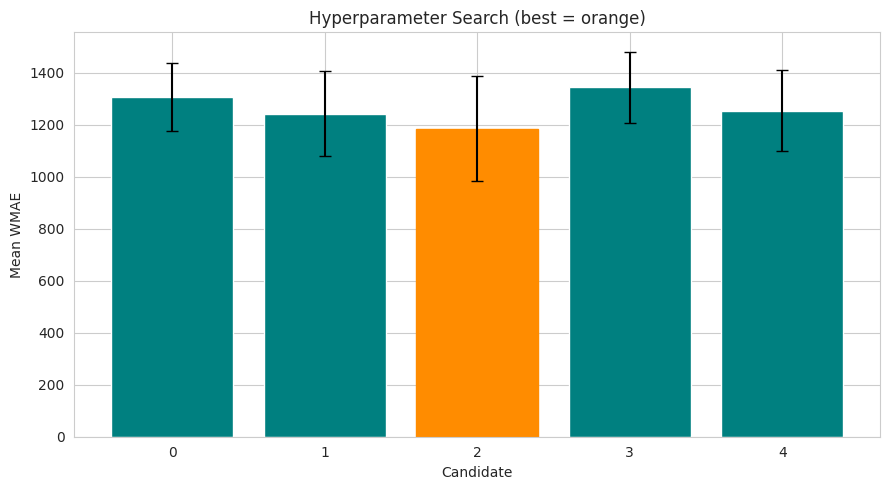

Best params: {'reg_lambda': 2.0, 'max_depth': 12, 'reg_alpha': 0.2, 'learning_rate': 0.03, 'subsample': 0.8, 'min_child_weight': 3, 'colsample_bytree': 0.8, 'n_estimators': 1000}
Best search WMAE: 1184.5391349617198


In [12]:
param_grid = [
    {'n_estimators': 800,  'max_depth': 8,  'learning_rate': 0.03, 'subsample': 0.8,
     'colsample_bytree': 0.7, 'min_child_weight': 3, 'reg_lambda': 1.0},
    {'n_estimators': 1200, 'max_depth': 10, 'learning_rate': 0.02, 'subsample': 0.75,
     'colsample_bytree': 0.7, 'min_child_weight': 5, 'reg_lambda': 1.5},
    {'n_estimators': 1000, 'max_depth': 12, 'learning_rate': 0.03, 'subsample': 0.8,
     'colsample_bytree': 0.8, 'min_child_weight': 3, 'reg_lambda': 2.0, 'reg_alpha': 0.2},
    {'n_estimators': 1500, 'max_depth': 8,  'learning_rate': 0.015, 'subsample': 0.85,
     'colsample_bytree': 0.65, 'min_child_weight': 4, 'reg_lambda': 2.5},
    {'n_estimators': 1000, 'max_depth': 9,  'learning_rate': 0.025, 'subsample': 0.8,
     'colsample_bytree': 0.75, 'min_child_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 0.5},
]


def cv_score(xgb_params, folds):
    fold_wmaes = []
    for tr_idx, va_idx in folds:
        pipe = build_pipeline(xgb_params)
        X_tr = train_fe.loc[tr_idx, feature_cols]
        y_tr = train_fe.loc[tr_idx, TARGET]

        # Freeze origin_* on validation rows at the fold's train cutoff, mirroring
        # the real test-time setup (fixes the CV/leaderboard mismatch).
        X_va_full = apply_frozen_origin(train_fe, tr_idx, va_idx, ORIGIN_LAGS)
        X_va = X_va_full[feature_cols]
        y_va = train_fe.loc[va_idx, TARGET]

        fit_pipeline(pipe, X_tr, y_tr, train_fe.loc[tr_idx, 'IsHoliday'])
        preds = predict_pipeline(pipe, X_va)
        fold_wmaes.append(wmae(y_va, preds, train_fe.loc[va_idx, 'IsHoliday']))
    return fold_wmaes


# Use later folds (closer to test regime) for search — more realistic WMAE
search_folds = row_folds[-3:]
search_results = []

with mlflow.start_run(run_name='XGBoost_Hyperparameter_Search') as parent_run:
    mlflow.log_param('n_search_folds', len(search_folds))
    mlflow.log_param('n_candidates', len(param_grid))
    mlflow.log_param('horizon_weeks', HORIZON_WEEKS)
    mlflow.log_param('safe_lags', SAFE_LAGS)
    mlflow.log_param('origin_lags', ORIGIN_LAGS)
    mlflow.log_param('use_log_target', USE_LOG_TARGET)

    for i, params in enumerate(param_grid):
        with mlflow.start_run(run_name=f'candidate_{i}', nested=True):
            mlflow.log_params({k: v for k, v in params.items()})
            fold_wmaes = cv_score(params, search_folds)
            mean_wmae = float(np.mean(fold_wmaes))
            std_wmae = float(np.std(fold_wmaes))
            mlflow.log_metric('mean_wmae', mean_wmae)
            mlflow.log_metric('std_wmae', std_wmae)
            for j, w in enumerate(fold_wmaes):
                mlflow.log_metric(f'wmae_fold{j+1}', float(w))
            search_results.append({'candidate': i, **params, 'mean_wmae': mean_wmae, 'std_wmae': std_wmae})
            print(f'Candidate {i}: mean WMAE = {mean_wmae:.2f} (+/- {std_wmae:.2f})')

search_df = pd.DataFrame(search_results).sort_values('mean_wmae').reset_index(drop=True)
display(search_df)

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = search_df.sort_values('candidate')
bars = ax.bar(plot_df['candidate'].astype(str), plot_df['mean_wmae'],
              yerr=plot_df['std_wmae'], capsize=4, color='teal')
best_cand = int(search_df.iloc[0]['candidate'])
bars[list(plot_df['candidate']).index(best_cand)].set_color('darkorange')
ax.set_xlabel('Candidate')
ax.set_ylabel('Mean WMAE')
ax.set_title('Hyperparameter Search (best = orange)')
plt.tight_layout()
plt.savefig('fig_hyperparam_search.png', bbox_inches='tight')
plt.show()

best_row = search_df.iloc[0]
param_keys = set()
for p in param_grid:
    param_keys |= set(p.keys())
best_params = {k: best_row[k] for k in param_keys if k in best_row.index and pd.notna(best_row[k])}
for k in ('n_estimators', 'max_depth', 'min_child_weight'):
    if k in best_params:
        best_params[k] = int(best_params[k])
for k in ('learning_rate', 'subsample', 'colsample_bytree', 'reg_lambda', 'reg_alpha'):
    if k in best_params:
        best_params[k] = float(best_params[k])

print('Best params:', best_params)
print('Best search WMAE:', float(best_row['mean_wmae']))


## 7. CSV

In [13]:
oof_records = []
fold_metrics = []
fold_importances = []

with mlflow.start_run(run_name='XGBoost_CrossValidation') as cv_run:
    mlflow.log_params(best_params)
    mlflow.log_param('n_splits', N_SPLITS)
    mlflow.log_param('lags', SAFE_LAGS)
    mlflow.log_param('rolling_windows', SAFE_ROLLING)
    mlflow.log_param('origin_lags', ORIGIN_LAGS)
    mlflow.log_param('n_features', len(feature_cols))
    mlflow.log_param('horizon_weeks', HORIZON_WEEKS)
    mlflow.log_param('sample_weight_holiday', 5)
    mlflow.log_param('use_log_target', USE_LOG_TARGET)

    for i, (tr_idx, va_idx) in enumerate(row_folds):
        pipe = build_pipeline(best_params)
        X_tr = train_fe.loc[tr_idx, feature_cols]
        y_tr = train_fe.loc[tr_idx, TARGET]

        # Freeze origin_* on validation rows at the fold's train cutoff, mirroring
        # the real test-time setup (fixes the CV/leaderboard mismatch).
        X_va_full = apply_frozen_origin(train_fe, tr_idx, va_idx, ORIGIN_LAGS)
        X_va = X_va_full[feature_cols]
        y_va = train_fe.loc[va_idx, TARGET]

        fit_pipeline(pipe, X_tr, y_tr, train_fe.loc[tr_idx, 'IsHoliday'])
        preds = predict_pipeline(pipe, X_va)

        baseline = (
            train_fe.loc[va_idx, BASELINE_COL].to_numpy()
            if BASELINE_COL is not None else np.full(len(va_idx), np.nan)
        )

        metrics = evaluate_predictions(y_va, preds, train_fe.loc[va_idx, 'IsHoliday'])
        metrics['fold'] = i + 1
        fold_metrics.append(metrics)

        mlflow.log_metric(f'wmae_fold{i+1}', metrics['wmae'])
        mlflow.log_metric(f'mae_fold{i+1}', metrics['mae'])
        mlflow.log_metric(f'rmse_fold{i+1}', metrics['rmse'])

        oof_records.append(pd.DataFrame({
            'Date': train_fe.loc[va_idx, 'Date'].values,
            'Store': train_fe.loc[va_idx, 'Store'].values,
            'Dept': train_fe.loc[va_idx, 'Dept'].values,
            'IsHoliday': train_fe.loc[va_idx, 'IsHoliday'].values,
            'y_true': np.asarray(y_va, dtype=float),
            'y_pred': preds,
            'baseline': baseline,
            'fold': i + 1,
        }))

        fold_importances.append(pipe.named_steps['model'].feature_importances_)
        print(f"Fold {i+1}: WMAE={metrics['wmae']:.2f}  MAE={metrics['mae']:.2f}  RMSE={metrics['rmse']:.2f}")

    metrics_df = pd.DataFrame(fold_metrics)
    mean_wmae = float(metrics_df['wmae'].mean())
    std_wmae  = float(metrics_df['wmae'].std())
    mlflow.log_metric('mean_wmae', mean_wmae)
    mlflow.log_metric('std_wmae', std_wmae)
    mlflow.log_metric('mean_mae', float(metrics_df['mae'].mean()))
    mlflow.log_metric('mean_rmse', float(metrics_df['rmse'].mean()))
    print(f'\nRaw XGB mean WMAE: {mean_wmae:.2f} (+/- {std_wmae:.2f})')

oof_df = pd.concat(oof_records, ignore_index=True)
oof_df['residual'] = oof_df['y_true'] - oof_df['y_pred']

# Tune blend: final = alpha * xgb + (1-alpha) * store_dept_week_avg
BLEND_ALPHA = 1.0
if BASELINE_COL is not None and oof_df['baseline'].notna().mean() > 0.9:
    blend_rows = []
    for a in np.linspace(0.0, 1.0, 21):
        blended = a * oof_df['y_pred'] + (1 - a) * oof_df['baseline'].fillna(oof_df['y_pred'])
        score = wmae(oof_df['y_true'], blended, oof_df['IsHoliday'])
        blend_rows.append({'alpha': a, 'wmae': score})
    blend_df = pd.DataFrame(blend_rows).sort_values('wmae')
    BLEND_ALPHA = float(blend_df.iloc[0]['alpha'])
    print('\nBlend search (alpha * XGB + (1-alpha) * store_dept_week_avg):')
    display(blend_df.head(5))
    print(f'Best BLEND_ALPHA = {BLEND_ALPHA:.2f} | OOF WMAE = {blend_df.iloc[0]["wmae"]:.2f}')

    oof_df['y_pred_blended'] = (
        BLEND_ALPHA * oof_df['y_pred']
        + (1 - BLEND_ALPHA) * oof_df['baseline'].fillna(oof_df['y_pred'])
    )
    mean_wmae = float(wmae(oof_df['y_true'], oof_df['y_pred_blended'], oof_df['IsHoliday']))
    print(f'Blended OOF WMAE: {mean_wmae:.2f}')
else:
    oof_df['y_pred_blended'] = oof_df['y_pred']
    print('No baseline column — skipping blend (BLEND_ALPHA=1.0)')

display(metrics_df)


Fold 1: WMAE=1735.23  MAE=1535.78  RMSE=6724.63
Fold 2: WMAE=1279.74  MAE=1293.36  RMSE=2964.22
Fold 3: WMAE=1345.56  MAE=1161.85  RMSE=3623.67
Fold 4: WMAE=1308.05  MAE=1262.92  RMSE=3031.80
Fold 5: WMAE=900.02  MAE=890.82  RMSE=2170.43

Raw XGB mean WMAE: 1313.72 (+/- 296.24)
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/40ab064b00604b6980b339eacb839ac4
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0

Blend search (alpha * XGB + (1-alpha) * store_dept_week_avg):


,alpha,wmae
4,0.20,1094.848591
5,0.25,1095.296809
3,0.15,1096.864922
6,0.30,1098.177765
2,0.10,1101.425326


Best BLEND_ALPHA = 0.20 | OOF WMAE = 1094.85
Blended OOF WMAE: 1094.85


,wmae,mae,rmse,fold
0,1735.233149,1535.780973,6724.633415,1
1,1279.735467,1293.355907,2964.224453,2
2,1345.555696,1161.852261,3623.674388,3
3,1308.046632,1262.918755,3031.801591,4
4,900.015078,890.818838,2170.427952,5


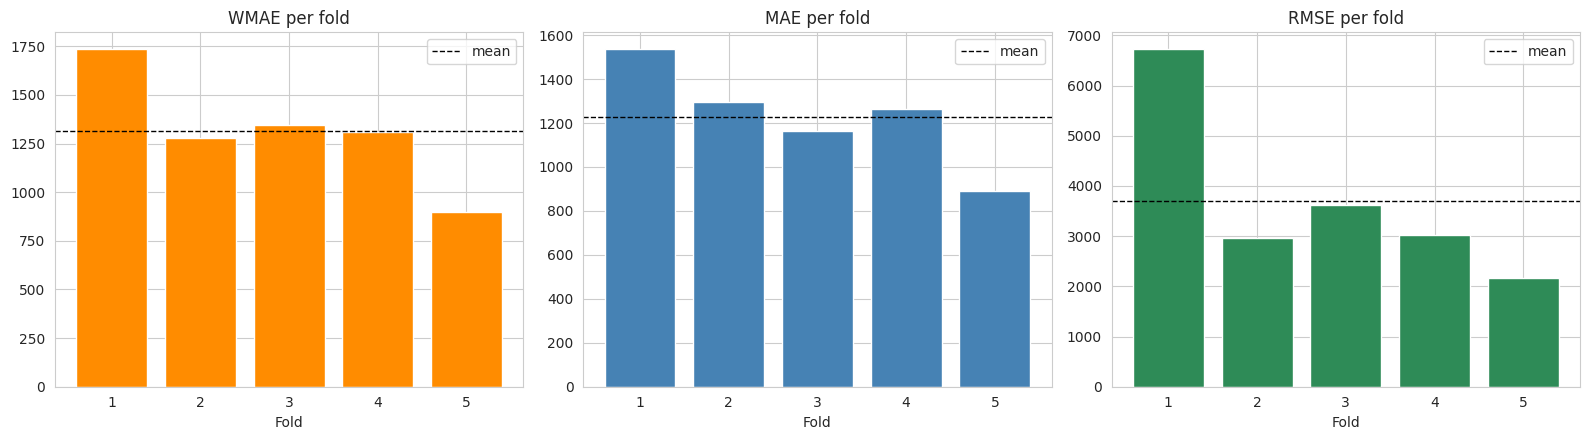

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, color in zip(axes, ['wmae', 'mae', 'rmse'], ['darkorange', 'steelblue', 'seagreen']):
    ax.bar(metrics_df['fold'].astype(str), metrics_df[metric], color=color)
    ax.axhline(metrics_df[metric].mean(), color='black', ls='--', lw=1, label='mean')
    ax.set_title(metric.upper() + ' per fold')
    ax.set_xlabel('Fold')
    ax.legend()
plt.tight_layout()
plt.savefig('fig_cv_metrics.png', bbox_inches='tight')
plt.show()


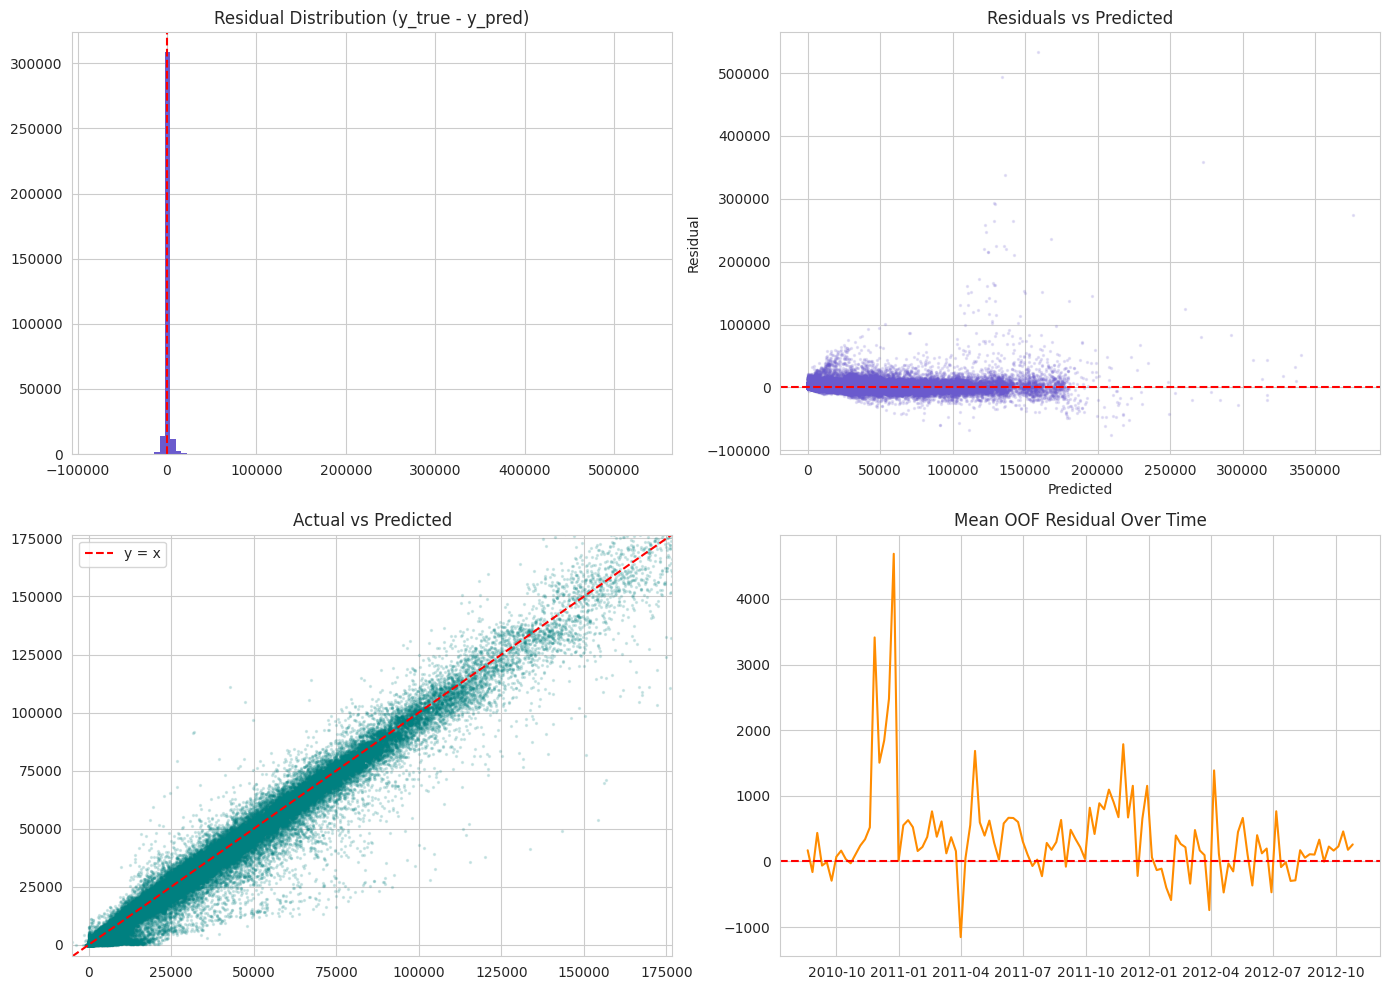

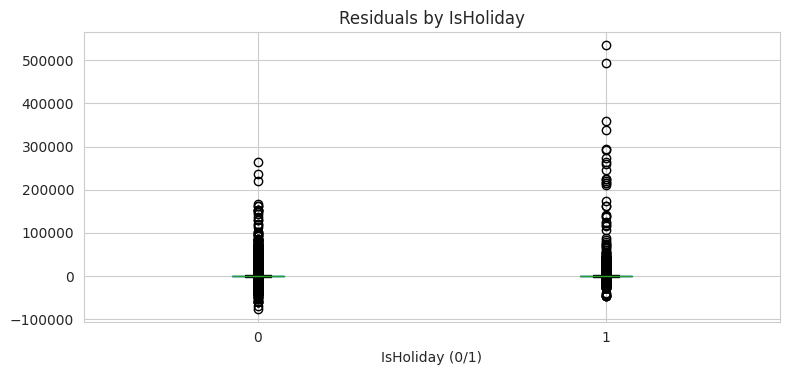

WMAE holiday weeks   : 1677.9660433577064
WMAE non-holiday     : 1190.035305576912


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].hist(oof_df['residual'], bins=100, color='slateblue', edgecolor='none')
axes[0][0].axvline(0, color='red', ls='--')
axes[0][0].set_title('Residual Distribution (y_true - y_pred)')

axes[0][1].scatter(oof_df['y_pred'], oof_df['residual'], s=2, alpha=0.15, color='slateblue')
axes[0][1].axhline(0, color='red', ls='--')
axes[0][1].set_title('Residuals vs Predicted')
axes[0][1].set_xlabel('Predicted')
axes[0][1].set_ylabel('Residual')

lims = [oof_df[['y_true', 'y_pred']].min().min(), oof_df[['y_true', 'y_pred']].quantile(0.999).max()]
axes[1][0].scatter(oof_df['y_true'], oof_df['y_pred'], s=2, alpha=0.15, color='teal')
axes[1][0].plot(lims, lims, color='red', ls='--', label='y = x')
axes[1][0].set_xlim(lims); axes[1][0].set_ylim(lims)
axes[1][0].set_title('Actual vs Predicted')
axes[1][0].legend()

weekly_resid = oof_df.groupby('Date')['residual'].mean()
axes[1][1].plot(weekly_resid.index, weekly_resid.values, color='darkorange')
axes[1][1].axhline(0, color='red', ls='--')
axes[1][1].set_title('Mean OOF Residual Over Time')

plt.tight_layout()
plt.savefig('fig_residual_diagnostics.png', bbox_inches='tight')
plt.show()

# Holiday vs non-holiday residual comparison (needed for report)
fig, ax = plt.subplots(figsize=(8, 4))
oof_df.boxplot(column='residual', by='IsHoliday', ax=ax)
ax.set_title('Residuals by IsHoliday')
ax.set_xlabel('IsHoliday (0/1)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('fig_residuals_by_holiday.png', bbox_inches='tight')
plt.show()

print('WMAE holiday weeks   :', wmae(
    oof_df.loc[oof_df.IsHoliday == 1, 'y_true'],
    oof_df.loc[oof_df.IsHoliday == 1, 'y_pred'],
    oof_df.loc[oof_df.IsHoliday == 1, 'IsHoliday']))
print('WMAE non-holiday     :', wmae(
    oof_df.loc[oof_df.IsHoliday == 0, 'y_true'],
    oof_df.loc[oof_df.IsHoliday == 0, 'y_pred'],
    oof_df.loc[oof_df.IsHoliday == 0, 'IsHoliday']))


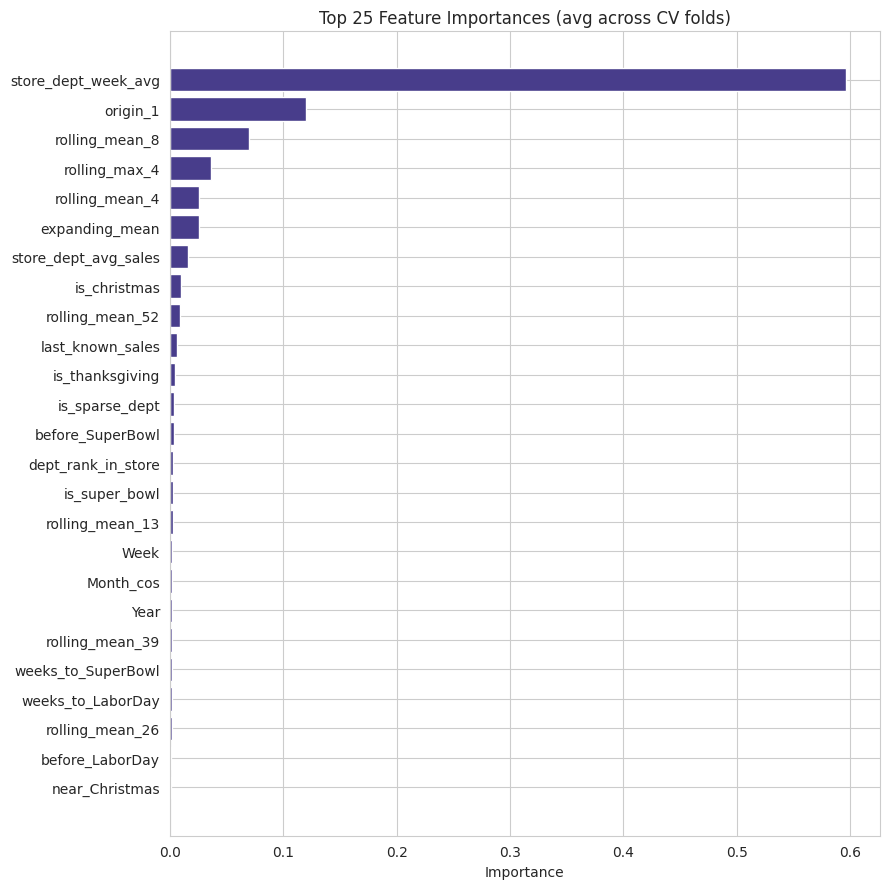

,feature,importance
0,store_dept_week_avg,0.596433
1,origin_1,0.120056
2,rolling_mean_8,0.069754
3,rolling_max_4,0.036171
4,rolling_mean_4,0.025827
5,expanding_mean,0.025446
6,store_dept_avg_sales,0.016005
7,is_christmas,0.010265
8,rolling_mean_52,0.008578
9,last_known_sales,0.006499


In [16]:
# Align importances by feature name — folds can differ if an older imputer dropped all-NaN cols
imp_frames = []
for imp in fold_importances:
    imp = np.asarray(imp, dtype=float)
    n = len(imp)
    names = PIPELINE_FEATURE_ORDER[:n] if n <= len(PIPELINE_FEATURE_ORDER) else [
        f'f{i}' for i in range(n)
    ]
    imp_frames.append(pd.Series(imp, index=names))

importance_df = (
    pd.concat(imp_frames, axis=1)
    .mean(axis=1)
    .rename('importance')
    .reset_index()
    .rename(columns={'index': 'feature'})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

top_n = 25
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(importance_df['feature'][:top_n][::-1],
        importance_df['importance'][:top_n][::-1],
        color='darkslateblue')
ax.set_title(f'Top {top_n} Feature Importances (avg across CV folds)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
display(importance_df.head(15))


In [17]:
REGISTERED_MODEL_NAME = 'walmart_xgboost_sales_forecaster'


class WalmartSalesPipeline(BaseEstimator):
    '''Imputer + XGB (+ optional log target). Blend is applied outside via BLEND_ALPHA.'''

    def __init__(self, sklearn_pipeline, feature_cols, use_log_target=True):
        self.sklearn_pipeline = sklearn_pipeline
        self.feature_cols = list(feature_cols)
        self.use_log_target = use_log_target

    def fit(self, X, y, is_holiday=None):
        X = X[self.feature_cols]
        if is_holiday is None:
            is_holiday = X['IsHoliday'] if 'IsHoliday' in X.columns else np.zeros(len(X))
        sw = np.where(np.asarray(is_holiday).astype(bool), 5.0, 1.0)
        y_fit = np.asarray(y, dtype=float)
        if self.use_log_target:
            y_fit = np.log1p(np.clip(y_fit, 0, None))
        self.sklearn_pipeline.fit(X, y_fit, model__sample_weight=sw)
        return self

    def predict(self, X):
        X = X[self.feature_cols]
        pred = self.sklearn_pipeline.predict(X)
        if self.use_log_target:
            pred = np.expm1(pred)
        return np.clip(pred, 0, None)


with mlflow.start_run(run_name='XGBoost_Final_Model') as final_run:
    mlflow.log_params(best_params)
    mlflow.log_param('n_features', len(feature_cols))
    mlflow.log_param('lags', SAFE_LAGS)
    mlflow.log_param('rolling_windows', SAFE_ROLLING)
    mlflow.log_param('origin_lags', ORIGIN_LAGS)
    mlflow.log_param('horizon_weeks', HORIZON_WEEKS)
    mlflow.log_param('use_log_target', USE_LOG_TARGET)
    mlflow.log_param('blend_alpha', BLEND_ALPHA)
    mlflow.log_metric('cv_mean_wmae', float(mean_wmae))
    mlflow.log_metric('cv_std_wmae', float(std_wmae))

    sk_pipe = build_pipeline(best_params)
    final_model = WalmartSalesPipeline(sk_pipe, feature_cols, use_log_target=USE_LOG_TARGET)
    final_model.fit(
        train_fe[feature_cols],
        train_fe[TARGET],
        is_holiday=train_fe['IsHoliday'],
    )

    for fig_path in [
        'fig_lag_missingness.png', 'fig_cv_scheme.png', 'fig_hyperparam_search.png',
        'fig_cv_metrics.png', 'fig_residual_diagnostics.png',
        'fig_residuals_by_holiday.png', 'fig_feature_importance.png',
    ]:
        if os.path.exists(fig_path):
            mlflow.log_artifact(fig_path)

    with open('feature_cols_xgboost.json', 'w') as f:
        json.dump(feature_cols, f)
    mlflow.log_artifact('feature_cols_xgboost.json')

    import joblib
    local_dir = '/kaggle/working' if os.path.isdir('/kaggle') else 'artifacts'
    os.makedirs(local_dir, exist_ok=True)
    model_path = os.path.join(local_dir, 'walmart_xgb_pipeline.joblib')
    joblib.dump({
        'model': final_model,
        'feature_cols': feature_cols,
        'best_params': best_params,
        'safe_lags': SAFE_LAGS,
        'safe_rolling': SAFE_ROLLING,
        'origin_lags': ORIGIN_LAGS,
        'blend_alpha': BLEND_ALPHA,
        'baseline_col': BASELINE_COL,
        'use_log_target': USE_LOG_TARGET,
        'cv_mean_wmae': mean_wmae,
    }, model_path)
    mlflow.log_artifact(model_path)
    print('Saved local pipeline ->', model_path)
    print(f'BLEND_ALPHA={BLEND_ALPHA:.2f}, USE_LOG_TARGET={USE_LOG_TARGET}')

    try:
        mlflow.sklearn.log_model(
            sk_model=final_model,
            artifact_path='model',
            registered_model_name=REGISTERED_MODEL_NAME if use_dagshub else None,
        )
        print('Logged model to MLflow',
              f'(registered as {REGISTERED_MODEL_NAME})' if use_dagshub else '(unregistered local)')
    except Exception as e:
        print('MLflow model logging skipped/failed:', e)

    final_run_id = final_run.info.run_id
    print('Final run ID:', final_run_id)


2026/07/21 10:15:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saved local pipeline -> /kaggle/working/walmart_xgb_pipeline.joblib
BLEND_ALPHA=0.20, USE_LOG_TARGET=True
MLflow model logging skipped/failed: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['__main__.WalmartSalesPipeline', 'numpy.dtype', 'sklearn.compose._column_transformer._RemainderColsList', 'xgboost.core.Booster', 'xgboost.sklearn.XGBRegressor'].
Final run ID: ac1031b8f3e2472283b265f051cd1730
🏃 View run XGBoost_Final_Model at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0/runs/ac1031b8f3e2472283b265f051cd1730
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/0


In [18]:
# Predict + CV-tuned blend with seasonal baseline
xgb_pred = final_model.predict(test_fe[feature_cols])

if BASELINE_COL is not None and BLEND_ALPHA < 1.0:
    baseline = test_fe[BASELINE_COL].to_numpy(dtype=float)
    # cold-start fallback
    baseline = np.where(np.isfinite(baseline), baseline, xgb_pred)
    test_pred = BLEND_ALPHA * xgb_pred + (1.0 - BLEND_ALPHA) * baseline
    print(f'Applied blend: {BLEND_ALPHA:.2f} * XGB + {1-BLEND_ALPHA:.2f} * {BASELINE_COL}')
else:
    test_pred = xgb_pred
    print('Using pure XGB predictions (no blend)')

test_pred = np.clip(test_pred, 0, None)

submission = pd.DataFrame({
    'Id': (test_fe['Store'].astype(str) + '_' + test_fe['Dept'].astype(str) + '_'
           + test_fe['Date'].dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': test_pred,
})

out_dir = '/kaggle/working' if os.path.isdir('/kaggle') else '.'
sub_path = os.path.join(out_dir, 'submission_xgboost.csv')
submission.to_csv(sub_path, index=False)

print(submission.head(10))
print(f'\nSubmission shape: {submission.shape}')
print(f'Weekly_Sales — min={submission.Weekly_Sales.min():.2f}, '
      f'mean={submission.Weekly_Sales.mean():.2f}, max={submission.Weekly_Sales.max():.2f}')
print('Wrote', sub_path)
print(f'Train Weekly_Sales mean: {train_fe.Weekly_Sales.mean():.2f}')
print(f'Test  prediction mean  : {submission.Weekly_Sales.mean():.2f}')

# Holiday-week sanity (Thanksgiving 2012-11-23, Christmas 2012-12-28)
for d in ['2012-11-23', '2012-12-28']:
    m = submission['Id'].str.endswith(d)
    if m.any():
        print(f'{d} mean pred: {submission.loc[m, "Weekly_Sales"].mean():.1f} (n={m.sum()})')


Applied blend: 0.20 * XGB + 0.80 * store_dept_week_avg
               Id  Weekly_Sales
0  1_1_2012-11-02  36665.581469
1  1_1_2012-11-09  19202.487283
2  1_1_2012-11-16  19569.711523
3  1_1_2012-11-23  20193.170199
4  1_1_2012-11-30  23781.154375
5  1_1_2012-12-07  31896.506613
6  1_1_2012-12-14  44475.580609
7  1_1_2012-12-21  49818.503719
8  1_1_2012-12-28  20928.490396
9  1_1_2013-01-04  16184.783230

Submission shape: (115064, 2)
Weekly_Sales — min=0.00, mean=15878.93, max=601266.73
Wrote /kaggle/working/submission_xgboost.csv
Train Weekly_Sales mean: 15981.26
Test  prediction mean  : 15878.93
2012-11-23 mean pred: 22030.8 (n=2976)
2012-12-28 mean pred: 13969.4 (n=2988)


In [19]:
## New cell — Christmas week-shift post-processing for XGBoost predictions

def apply_christmas_shift(df, value_col, threshold=1.1, shift_days=2.5):
    """
    Same correction used on the Prophet pipeline — redistributes Nov/Dec
    predictions across ISO weeks 48-52 to correct for Christmas landing on
    a different weekday each year. Works on any Store/Dept/Date/value frame,
    so it applies just as well to XGBoost output as to Prophet's.
    """
    d = df.copy()
    d['Date'] = pd.to_datetime(d['Date'])
    d['iso_week'] = d['Date'].dt.isocalendar().week.astype(int)

    holiday_weeks = [48, 49, 50, 51, 52]
    mask = d['iso_week'].isin(holiday_weeks)
    if not mask.any():
        print("No weeks 48-52 present — skipping shift.")
        return df

    adjusted_frames = [d[~mask].drop(columns='iso_week')]
    n_shifted = 0

    for dept_i, dept_df in d[mask].groupby('Dept'):
        pivot = dept_df.pivot_table(index='iso_week', columns='Store',
                                     values=value_col, aggfunc='mean')
        pivot = pivot.reindex(holiday_weeks)

        if pivot.isnull().all(axis=None) or len(pivot) < 5:
            adjusted_frames.append(dept_df.drop(columns='iso_week'))
            continue

        baseline = pd.concat([pivot.iloc[0], pivot.iloc[4]], axis=1).mean(axis=1).mean()
        surge = pivot.iloc[1:4].mean(axis=1).mean()
        ratio = surge / baseline if baseline and np.isfinite(baseline) and baseline != 0 else np.nan

        if np.isfinite(ratio) and ratio > threshold:
            holiday = pivot.fillna(0)
            shifted = ((7 - shift_days) / 7) * holiday
            shifted.iloc[1:5] = shifted.iloc[1:5].values + (shift_days / 7) * holiday.iloc[0:4].values
            shifted.iloc[0] = holiday.iloc[0]
            pivot = shifted
            n_shifted += 1

        lookup = pivot.stack()
        dept_df = dept_df.copy()
        dept_df[value_col] = dept_df.apply(
            lambda row: lookup.get((row['iso_week'], row['Store']), row[value_col]),
            axis=1
        )
        adjusted_frames.append(dept_df.drop(columns='iso_week'))

    print(f"Departments shifted: {n_shifted} / {d[mask]['Dept'].nunique()}")
    return pd.concat(adjusted_frames, ignore_index=True)


# --- Apply to the test predictions already built in Cell 25 ---
pred_frame = pd.DataFrame({
    'Store': test_fe['Store'].values,
    'Dept': test_fe['Dept'].values,
    'Date': test_fe['Date'].values,
    'Weekly_Sales': test_pred,
})
pred_frame_shifted = apply_christmas_shift(pred_frame, value_col='Weekly_Sales', threshold=1.1, shift_days=2.5)

submission_shifted = pd.DataFrame({
    'Id': (pred_frame_shifted['Store'].astype(str) + '_' + pred_frame_shifted['Dept'].astype(str) + '_'
           + pd.to_datetime(pred_frame_shifted['Date']).dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': pred_frame_shifted['Weekly_Sales'],
})

sub_path_shifted = os.path.join(out_dir, 'submission_xgboost_shifted.csv')
submission_shifted.to_csv(sub_path_shifted, index=False)
print(f"Rows: {len(submission_shifted)} (expect {len(test_fe)})")
print(f"Any nulls: {submission_shifted['Weekly_Sales'].isnull().sum()}")
print("Wrote", sub_path_shifted)

Departments shifted: 66 / 80
Rows: 115064 (expect 115064)
Any nulls: 0
Wrote /kaggle/working/submission_xgboost_shifted.csv


In [22]:
from IPython.display import FileLink
FileLink('submission_xgboost_shifted.csv')

/kaggle/working/submission_xgboost_shifted.csv